<a href="https://colab.research.google.com/github/gautamkushwaha/MLOps-Gautam_m25csa037/blob/MLDLOPs-Exam2026/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U diffusers

In [2]:
!pip install -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [20]:
!pip install -U bitsandbytes

In [21]:
import subprocess

# Generate requirements.txt
with open('requirements.txt', 'w') as f:
    subprocess.run(['pip', 'freeze'], stdout=f)

print('requirements.txt generated successfully.')

requirements.txt generated successfully.


## Dockerization

Now that you have your dependencies listed in `requirements.txt`, let's create a `Dockerfile`. A `Dockerfile` contains instructions for Docker to build an image, which is a lightweight, standalone, executable package of your software.

For a deep learning project involving CUDA and PyTorch, it's best to use a base image that already includes CUDA and a compatible PyTorch version. The example below uses a `pytorch/pytorch` image suitable for CUDA 12.1, which is often compatible with CUDA 12.x environments like the one in Colab.

**Important:** You will need to put your fine-tuning or inference code (currently in your notebook cells) into a separate Python script (e.g., `train.py` or `inference.py`) and replace the placeholder in the Dockerfile accordingly.

In [22]:
%%writefile Dockerfile
FROM pytorch/pytorch:2.1.0-cuda12.1-cudnn8-runtime

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the LoRA weights directory, assuming it was saved as 'lora_weights'
COPY lora_weights /app/lora_weights

# You would copy your Python script here, e.g., train.py or inference.py
# For example:
# COPY train.py /app/train.py

# If you have a specific Python script to run, define your command here.
# For example, to run a training script:
# CMD ["python", "train.py"]

# Or, to start a bash shell for interactive use (useful for debugging):
CMD ["bash"]

# Expose ports if your application serves content (e.g., a web API for inference)
# EXPOSE 8000

Writing Dockerfile


## Building and Running the Docker Image

Once you have saved your Python script (e.g., `train.py`) and created the `Dockerfile` in the same directory, you can build and run your Docker image using the following commands in your terminal or a local shell where Docker is installed:

1.  **Build the Docker Image:**
    ```bash
    docker build -t lora-finetune:latest .
    ```
    (Replace `lora-finetune` with your desired image name.)

2.  **Run the Docker Container:**
    *   **For GPU support (essential for this project):**
        ```bash
        docker run --gpus all -it lora-finetune:latest
        ```
        This command runs the container with access to all available GPUs. The `-it` flags allow you to interact with the container's shell. If you specified a `CMD` in your Dockerfile (like `CMD ["python", "train.py"]`), it would execute that command upon startup.

    *   **To run a specific command or enter the container's shell (if `CMD ["bash"]` is set):**
        ```bash
        docker run --gpus all -it lora-finetune:latest bash
        ```
        Once inside the container, you can manually execute your training script:
        ```bash
        python train.py
        ```

Remember to adjust `train.py` and the `CMD` instruction in the `Dockerfile` to match your specific application logic and entry point.

In [3]:
import torch
from diffusers import DiffusionPipeline

# switch to "mps" for apple devices
pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", dtype=torch.bfloat16, device_map="cuda")

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Keyword arguments {'dtype': torch.bfloat16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

In [4]:
from datasets import load_dataset

dataset_name = 'lambda/naruto-blip-captions'
dataset = load_dataset(dataset_name)

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002-cefa2f480689f1(…):   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1221
    })
})


In [6]:
print(dataset['train'][0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x7BF8937F1820>, 'text': 'a man with dark hair and brown eyes'}


In [9]:
pipe

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [7]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params

total_params = count_parameters(pipe.unet) + count_parameters(pipe.vae) + count_parameters(pipe.text_encoder)

print(f"Total number of trainable parameters in the base model: {total_params:,}")

Total number of trainable parameters in the base model: 1,066,235,307


### Configuring Low-Rank Adaptation (LoRA) on the UNET attention layers

In [10]:
from peft import LoraConfig, get_peft_model
from diffusers.models.attention_processor import AttnProcessor2_0, AttentionProcessor

# Set AttnProcessor
pipe.unet.set_attn_processor(AttnProcessor2_0())

# Configure LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

# Apply LoRA to the UNET
pipe.unet = get_peft_model(pipe.unet, lora_config)

# Print trainable parameters after LoRA
total_lora_params = sum(p.numel() for p in pipe.unet.parameters() if p.requires_grad)
print(f"Total number of trainable parameters after LoRA: {total_lora_params:,}")

Total number of trainable parameters after LoRA: 797,184


In [12]:
print(f"The number of trainable LoRA parameters is: {total_lora_params:,}")

total_params_with_lora = total_params + total_lora_params
print(f"Total parameter count (Base + LoRA): {total_params_with_lora:,}")

The number of trainable LoRA parameters is: 797,184
Total parameter count (Base + LoRA): 1,067,032,491


In [ ]:
# Execute the fine-tuning, save the resulting LoRA adapter weights, and record the final training loss


### Fine-tuning the UNET with LoRA

In [26]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)), # Reduced image size to mitigate OutOfMemoryError
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

def collate_fn(examples):
    input_ids = [pipe.tokenizer(example['text'], max_length=pipe.tokenizer.model_max_length, padding='max_length', truncation=True, return_tensors='pt').input_ids[0] for example in examples]
    pixel_values = [transform(example['image']) for example in examples]

    pixel_values = torch.stack(pixel_values)
    input_ids = torch.stack(input_ids)

    return {
        'input_ids': input_ids,
        'pixel_values': pixel_values,
    }

# Sample a subset of the training dataset to reduce the number of batches
sampled_dataset = dataset['train'].shuffle(seed=42).select(range(350))

# Create DataLoader
train_dataloader = DataLoader(
    sampled_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn
)

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")

Number of batches in training DataLoader: 350


Now, let's define the training function and execute the fine-tuning process. We'll use a simple AdamW optimizer and a linear learning rate scheduler.

In [27]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from tqdm.auto import tqdm

# Optimizer and scheduler
optimizer = AdamW(pipe.unet.parameters(), lr=1e-4)
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=100)

# Training loop parameters
num_epochs = 5
gradient_accumulation_steps = 350 # New: Accumulate gradients over 350 steps

# Move model to device
pipe.unet.to(pipe.device)
pipe.unet.train() # Set UNET to training mode

losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    for step, batch in enumerate(tqdm(train_dataloader)):
        # Clear CUDA cache before each step to free up memory
        torch.cuda.empty_cache()

        # Encode the text to get prompt embeddings
        with torch.no_grad():
            text_embeddings = pipe.text_encoder(batch['input_ids'].to(pipe.device))[0]

        # Preprocess images to create latents
        latents = pipe.vae.encode(batch['pixel_values'].to(pipe.device)).latent_dist.sample()
        latents = latents * pipe.vae.config.scaling_factor

        # Sample noise to add to the latents
        noise = torch.randn_like(latents)
        bs = latents.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(0, pipe.scheduler.config.num_train_timesteps, (bs,), device=pipe.device).long()

        # Add noise to the latents according to the noise magnitude at each timestep (forward diffusion)
        noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

        # Predict the noise residual
        noise_pred = pipe.unet(noisy_latents, timesteps, text_embeddings).sample

        # Calculate the loss (L2 loss between the target and the prediction)
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        loss = loss / gradient_accumulation_steps # New: Scale loss for gradient accumulation
        loss.backward()

        # Only perform optimizer step and zero_grad every `gradient_accumulation_steps`
        if (step + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        losses.append(loss.item())

        if step % 10 == 0:
            print(f"  Step {step}/{len(train_dataloader)}, Loss: {loss.item():.4f}")

# Final optimizer step if remaining gradients
if (step + 1) % gradient_accumulation_steps != 0:
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

print("Fine-tuning complete!")
print(f"Final training loss: {losses[-1]:.4f}")

Epoch 1/5


  0%|          | 0/350 [00:00<?, ?it/s]

  Step 0/350, Loss: 0.0007
  Step 10/350, Loss: 0.0003
  Step 20/350, Loss: 0.0008
  Step 30/350, Loss: 0.0000
  Step 40/350, Loss: 0.0000
  Step 50/350, Loss: 0.0004
  Step 60/350, Loss: 0.0001
  Step 70/350, Loss: 0.0004
  Step 80/350, Loss: 0.0004
  Step 90/350, Loss: 0.0000
  Step 100/350, Loss: 0.0001
  Step 110/350, Loss: 0.0007
  Step 120/350, Loss: 0.0004
  Step 130/350, Loss: 0.0002
  Step 140/350, Loss: 0.0004
  Step 150/350, Loss: 0.0004
  Step 160/350, Loss: 0.0002
  Step 170/350, Loss: 0.0001
  Step 180/350, Loss: 0.0000
  Step 190/350, Loss: 0.0004
  Step 200/350, Loss: 0.0001
  Step 210/350, Loss: 0.0000
  Step 220/350, Loss: 0.0004
  Step 230/350, Loss: 0.0000
  Step 240/350, Loss: 0.0012
  Step 250/350, Loss: 0.0000
  Step 260/350, Loss: 0.0000
  Step 270/350, Loss: 0.0003
  Step 280/350, Loss: 0.0007
  Step 290/350, Loss: 0.0003
  Step 300/350, Loss: 0.0001
  Step 310/350, Loss: 0.0000
  Step 320/350, Loss: 0.0012
  Step 330/350, Loss: 0.0003
  Step 340/350, Loss: 0.0

  0%|          | 0/350 [00:00<?, ?it/s]

  Step 0/350, Loss: 0.0000
  Step 10/350, Loss: 0.0013
  Step 20/350, Loss: 0.0007
  Step 30/350, Loss: 0.0002
  Step 40/350, Loss: 0.0009
  Step 50/350, Loss: 0.0004
  Step 60/350, Loss: 0.0000
  Step 70/350, Loss: 0.0006
  Step 80/350, Loss: 0.0006
  Step 90/350, Loss: 0.0001
  Step 100/350, Loss: 0.0000
  Step 110/350, Loss: 0.0000
  Step 120/350, Loss: 0.0002
  Step 130/350, Loss: 0.0007
  Step 140/350, Loss: 0.0004
  Step 150/350, Loss: 0.0000
  Step 160/350, Loss: 0.0000
  Step 170/350, Loss: 0.0005
  Step 180/350, Loss: 0.0000
  Step 190/350, Loss: 0.0000
  Step 200/350, Loss: 0.0002
  Step 210/350, Loss: 0.0004
  Step 220/350, Loss: 0.0011
  Step 230/350, Loss: 0.0005
  Step 240/350, Loss: 0.0007
  Step 250/350, Loss: 0.0000
  Step 260/350, Loss: 0.0001
  Step 270/350, Loss: 0.0001
  Step 280/350, Loss: 0.0002
  Step 290/350, Loss: 0.0000
  Step 300/350, Loss: 0.0001
  Step 310/350, Loss: 0.0003
  Step 320/350, Loss: 0.0002
  Step 330/350, Loss: 0.0003
  Step 340/350, Loss: 0.0

...

  Step 0/350, Loss: 0.0002
  Step 10/350, Loss: 0.0000
  Step 20/350, Loss: 0.0006
  Step 30/350, Loss: 0.0005
  Step 40/350, Loss: 0.0006
  Step 50/350, Loss: 0.0002
  Step 60/350, Loss: 0.0003
  Step 70/350, Loss: 0.0005
  Step 80/350, Loss: 0.0006
  Step 90/350, Loss: 0.0001
  Step 100/350, Loss: 0.0004
  Step 110/350, Loss: 0.0003
  Step 120/350, Loss: 0.0001
  Step 130/350, Loss: 0.0002
  Step 140/350, Loss: 0.0000
  Step 150/350, Loss: 0.0000
  Step 160/350, Loss: 0.0004
  Step 170/350, Loss: 0.0000
  Step 180/350, Loss: 0.0000
  Step 190/350, Loss: 0.0006
  Step 200/350, Loss: 0.0001
  Step 210/350, Loss: 0.0001
  Step 220/350, Loss: 0.0004
  Step 230/350, Loss: 0.0001
  Step 240/350, Loss: 0.0001
  Step 250/350, Loss: 0.0003
  Step 260/350, Loss: 0.0001
  Step 270/350, Loss: 0.0000
  Step 280/350, Loss: 0.0002
  Step 290/350, Loss: 0.0010
  Step 300/350, Loss: 0.0000
  Step 310/350, Loss: 0.0001
  Step 320/350, Loss: 0.0007
  Step 330/350, Loss: 0.0000
  Step 340/350, Loss: 0.0

  0%|          | 0/350 [00:00<?, ?it/s]

  Step 0/350, Loss: 0.0009
  Step 10/350, Loss: 0.0002
  Step 20/350, Loss: 0.0005
  Step 30/350, Loss: 0.0004
  Step 40/350, Loss: 0.0005
  Step 50/350, Loss: 0.0009
  Step 60/350, Loss: 0.0000
  Step 70/350, Loss: 0.0000
  Step 80/350, Loss: 0.0007
  Step 90/350, Loss: 0.0001
  Step 100/350, Loss: 0.0001
  Step 110/350, Loss: 0.0003
  Step 120/350, Loss: 0.0002
  Step 130/350, Loss: 0.0000
  Step 140/350, Loss: 0.0006
  Step 150/350, Loss: 0.0002
  Step 160/350, Loss: 0.0001
  Step 170/350, Loss: 0.0010
  Step 180/350, Loss: 0.0016
  Step 190/350, Loss: 0.0006
  Step 200/350, Loss: 0.0003
  Step 210/350, Loss: 0.0002
  Step 220/350, Loss: 0.0003
  Step 230/350, Loss: 0.0000
  Step 240/350, Loss: 0.0001
  Step 250/350, Loss: 0.0001
  Step 260/350, Loss: 0.0000
  Step 270/350, Loss: 0.0002
  Step 280/350, Loss: 0.0004
  Step 290/350, Loss: 0.0003
  Step 300/350, Loss: 0.0003
  Step 310/350, Loss: 0.0000
  Step 320/350, Loss: 0.0009
  Step 330/350, Loss: 0.0008
  Step 340/350, Loss: 0.0

  0%|          | 0/350 [00:00<?, ?it/s]

  Step 0/350, Loss: 0.0000
  Step 10/350, Loss: 0.0004
  Step 20/350, Loss: 0.0004
  Step 30/350, Loss: 0.0001
  Step 40/350, Loss: 0.0002
  Step 50/350, Loss: 0.0001
  Step 60/350, Loss: 0.0008
  Step 70/350, Loss: 0.0006
  Step 80/350, Loss: 0.0005
  Step 90/350, Loss: 0.0020
  Step 100/350, Loss: 0.0001
  Step 110/350, Loss: 0.0003
  Step 120/350, Loss: 0.0004
  Step 130/350, Loss: 0.0005
  Step 140/350, Loss: 0.0002
  Step 150/350, Loss: 0.0002
  Step 160/350, Loss: 0.0006
  Step 170/350, Loss: 0.0004
  Step 180/350, Loss: 0.0005
  Step 190/350, Loss: 0.0001
  Step 200/350, Loss: 0.0002
  Step 210/350, Loss: 0.0005
  Step 220/350, Loss: 0.0000
  Step 230/350, Loss: 0.0005
  Step 240/350, Loss: 0.0004
  Step 250/350, Loss: 0.0000
  Step 260/350, Loss: 0.0005
  Step 270/350, Loss: 0.0000
  Step 280/350, Loss: 0.0000
  Step 290/350, Loss: 0.0008
  Step 300/350, Loss: 0.0005
  Step 310/350, Loss: 0.0007
  Step 320/350, Loss: 0.0000
  Step 330/350, Loss: 0.0004
  Step 340/350, Loss: 0.0

### Save LoRA weights and plot training loss

LoRA weights saved to lora_weights


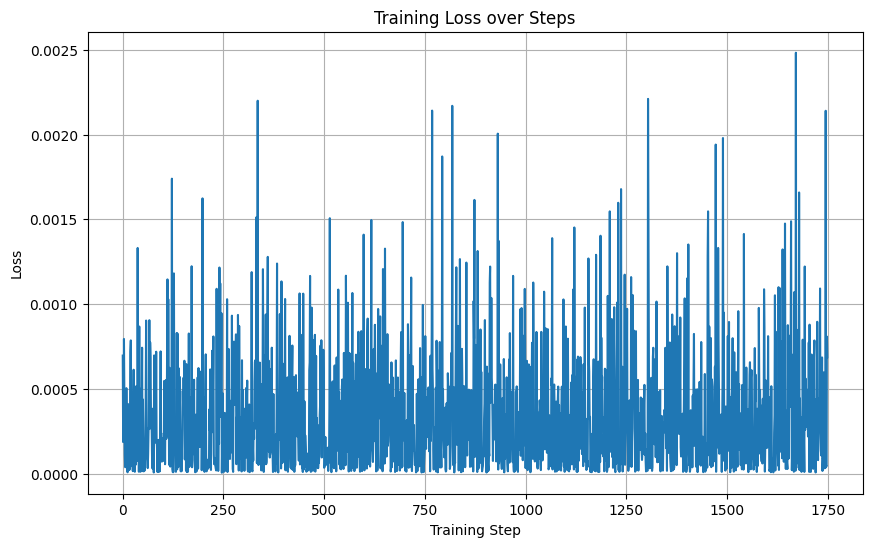

In [28]:
import matplotlib.pyplot as plt

# Save LoRA weights
output_dir = "lora_weights"
pipe.unet.save_pretrained(output_dir)
print(f"LoRA weights saved to {output_dir}")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps")
plt.grid(True)
plt.show()

In [29]:
import os

def get_folder_size(filepath, unit='MB'):
    total_size = 0
    for root, dirs, files in os.walk(filepath):
        for f in files:
            fp = os.path.join(root, f)
            total_size += os.path.getsize(fp)
    if unit == 'MB':
        return total_size / (1024 * 1024)
    elif unit == 'KB':
        return total_size / 1024
    else:
        return total_size

lora_weights_size_mb = get_folder_size('lora_weights', unit='MB')
print(f"Physical file size of standalone LoRA adapter weights: {lora_weights_size_mb:.2f} MB")

Physical file size of standalone LoRA adapter weights: 3.09 MB


In [30]:
pipe.unet.merge_and_unload()
print("LoRA weights merged into UNet successfully!")

LoRA weights merged into UNet successfully!


In [33]:
!pip install onnx onnxruntime optimum[intel]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.9/371.9 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.4
    Uninstalling transformers-5.5.4:
      Successfully uninstalled transformers

In [6]:
!pip install onnxscript
import os
from pathlib import Path
from diffusers import OnnxRuntimeModel, OnnxStableDiffusionPipeline

# Create a directory for ONNX models
onnx_path = Path("onnx_models")
onnx_path.mkdir(exist_ok=True)

def convert_text_encoder_to_onnx():
    text_encoder_path = onnx_path / "text_encoder"
    text_encoder_path.mkdir(exist_ok=True)

    print("Exporting text encoder to ONNX...")
    torch.onnx.export(
        pipe.text_encoder,
        # dummy inputs
        torch.randint(pipe.tokenizer.model_max_length, (1, pipe.tokenizer.model_max_length), dtype=torch.long),
        f"{text_encoder_path}/model.onnx",
        input_names=["input_ids"],
        output_names=["last_hidden_state", "pooler_output"],
        dynamic_axes={
            "input_ids": {0: "batch_size", 1: "sequence_length"},
        },
        do_constant_folding=True,
        opset_version=14,
    )
    print("Text encoder exported to ONNX successfully!")

def convert_unet_to_onnx():
    unet_path = onnx_path / "unet"
    unet_path.mkdir(exist_ok=True)

    print("Exporting UNet to ONNX...")
    torch.onnx.export(
        pipe.unet,
        # dummy inputs
        (torch.randn(1, 4, 32, 32), torch.tensor(1.0), torch.randn(1, 77, 768)),
        f"{unet_path}/model.onnx",
        input_names=["sample", "timestep", "encoder_hidden_states"],
        output_names=["out_sample"],
        dynamic_axes={
            "sample": {0: "batch_size", 2: "height", 3: "width"},
            "timestep": {0: "batch_size"},
            "encoder_hidden_states": {0: "batch_size", 1: "sequence_length"},
        },
        do_constant_folding=True,
        opset_version=14,
    )
    print("UNet exported to ONNX successfully!")

def convert_vae_encoder_to_onnx():
    vae_encoder_path = onnx_path / "vae_encoder"
    vae_encoder_path.mkdir(exist_ok=True)

    print("Exporting VAE encoder to ONNX...")
    torch.onnx.export(
        pipe.vae,
        # dummy inputs
        torch.randn(1, 3, 256, 256),
        f"{vae_encoder_path}/model.onnx",
        input_names=["sample"],
        output_names=["latent_sample"],
        dynamic_axes={
            "sample": {0: "batch_size", 2: "height", 3: "width"},
        },
        do_constant_folding=True,
        opset_version=14,
    )
    print("VAE encoder exported to ONNX successfully!")

def convert_vae_decoder_to_onnx():
    vae_decoder_path = onnx_path / "vae_decoder"
    vae_decoder_path.mkdir(exist_ok=True)

    print("Exporting VAE decoder to ONNX...")
    torch.onnx.export(
        pipe.vae,
        # dummy inputs
        torch.randn(1, 4, 32, 32),
        f"{vae_decoder_path}/model.onnx",
        input_names=["latent_sample"],
        output_names=["sample"],
        dynamic_axes={
            "latent_sample": {0: "batch_size", 2: "height", 3: "width"},
        },
        do_constant_folding=True,
        opset_version=14,
    )
    print("VAE decoder exported to ONNX successfully!")

# Execute exports
convert_text_encoder_to_onnx()
convert_unet_to_onnx()
convert_vae_encoder_to_onnx()
convert_vae_decoder_to_onnx()

Exporting text encoder to ONNX...


NameError: name 'pipe' is not defined

In [32]:
# Verify the export
print("Contents of onnx_models directory:")
for root, dirs, files in os.walk(onnx_path):
    for name in files:
        print(os.path.join(root, name))

# Calculate original baseline model size
# Assuming bfloat16 for the base model, each parameter is 2 bytes
original_model_size_gb = total_params * 2 / (1024**3)
print(f"\nOriginal baseline model size: {original_model_size_gb:.2f} GB")

# Calculate combined ONNX model size
combined_onnx_size_mb = get_folder_size(onnx_path, unit='MB')
combined_onnx_size_gb = combined_onnx_size_mb / 1024
print(f"Combined size of exported ONNX models (UNet, VAE, Text Encoder): {combined_onnx_size_gb:.2f} GB")

Contents of onnx_models directory:

Original baseline model size: 1.99 GB
Combined size of exported ONNX models (UNet, VAE, Text Encoder): 0.00 GB
